In [3]:
OWM_API_KEY = ""
GROQ_API_KEY = ""
print("✅ API keys set!")



✅ API keys set!


In [2]:
# # 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


# from openai import OpenAI
# import os
# client = OpenAI(
#     api_key=os.environ.get("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"),
#     base_url="https://api.groq.com/openai/v1",
# )

# response = client.responses.create(
#     input="Explain the importance of fast language models",
#     model="openai/gpt-oss-20b",
# )
# print(response.output_text)


In [4]:
!pip install -q xgboost shap groq gradio requests pandas numpy scikit-learn matplotlib seaborn plotly
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 1.3 MB/s eta 0:00:00
✅ Done!


In [5]:
import requests, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, warnings, math, json
import plotly.graph_objects as go, plotly.express as px, shap
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import groq as groq_client
warnings.filterwarnings('ignore')
shap.initjs()
print("✅ Imports done!")

✅ Imports done!


In [6]:
BASE_URL = "https://api.openweathermap.org/data/2.5"
GEO_URL  = "https://api.openweathermap.org/geo/1.0"

def get_coordinates(city):
    r = requests.get(f"{GEO_URL}/direct?q={city}&limit=1&appid={OWM_API_KEY}").json()
    if not r: raise ValueError(f"City '{city}' not found")
    return r[0]['lat'], r[0]['lon'], r[0].get('country','')

def get_weather(lat, lon):
    return requests.get(f"{BASE_URL}/weather?lat={lat}&lon={lon}&appid={OWM_API_KEY}&units=metric").json()

def get_air_pollution(lat, lon):
    return requests.get(f"{BASE_URL}/air_pollution?lat={lat}&lon={lon}&appid={OWM_API_KEY}").json()

def get_forecast(lat, lon):
    return requests.get(f"{BASE_URL}/forecast?lat={lat}&lon={lon}&appid={OWM_API_KEY}&units=metric&cnt=40").json()

def fetch_city_data(city):
    lat, lon, country = get_coordinates(city)
    return {
        'city': city, 'country': country, 'lat': lat, 'lon': lon,
        'weather': get_weather(lat, lon),
        'pollution': get_air_pollution(lat, lon),
        'forecast': get_forecast(lat, lon)
    }

print("✅ Fetch functions ready!")

✅ Fetch functions ready!


In [9]:
def heat_index(T, RH):
    Tf = T * 9/5 + 32
    HI = (-42.379 + 2.04901523*Tf + 10.14333127*RH - 0.22475541*Tf*RH
          - 0.00683783*Tf**2 - 0.05481717*RH**2 + 0.00122874*Tf**2*RH
          + 0.00085282*Tf*RH**2 - 0.00000199*Tf**2*RH**2)
    return (HI - 32) * 5/9

def dew_point(T, RH):
    a, b = 17.27, 237.7
    alpha = ((a * T) / (b + T)) + math.log(max(RH, 0.01) / 100.0)
    return (b * alpha) / (a - alpha)

def wet_bulb_temp(T, RH):
    return (T * math.atan(0.151977*(RH+8.313659)**0.5)
            + math.atan(T+RH) - math.atan(RH-1.676331)
            + 0.00391838*RH**1.5 * math.atan(0.023101*RH) - 4.686035)

def pollution_composite(c):
    weights  = {'pm2_5':0.35,'pm10':0.20,'no2':0.15,'o3':0.15,'co':0.10,'so2':0.05}
    max_vals = {'pm2_5':250,'pm10':430,'no2':400,'o3':240,'co':15400,'so2':1600}
    return round(sum(weights[k]*min(c.get(k,0)/max_vals[k],1.0)*500 for k in weights), 2)

def engineer_features(raw):
    w  = raw['weather']
    p  = raw['pollution']
    T  = w['main']['temp'];   RH = w['main']['humidity']
    Tf = w['main']['feels_like']
    Tmin = w['main']['temp_min']; Tmax = w['main']['temp_max']
    ws = w['wind']['speed'];  wd = w['wind'].get('deg', 0)
    cl = w['clouds']['all']; vis = w.get('visibility',10000)/1000
    wid = w['weather'][0]['id']
    pres = w['main']['pressure']
    comps = p['list'][0]['components']
    owm_aqi = p['list'][0]['main']['aqi']
    HI = heat_index(T, RH); DP = dew_point(T, RH); WB = wet_bulb_temp(T, RH)
    PC = pollution_composite(comps)
    return {
        'temperature':T, 'feels_like':Tf, 'humidity':RH, 'pressure':pres,
        'wind_speed':ws, 'cloud_cover':cl, 'visibility_km':vis,
        'pm2_5':comps.get('pm2_5',0), 'pm10':comps.get('pm10',0),
        'no2':comps.get('no2',0), 'o3':comps.get('o3',0),
        'co':comps.get('co',0), 'so2':comps.get('so2',0),
        'pollution_composite':PC,
        'pm_ratio':(comps.get('pm2_5',0)+0.001)/(comps.get('pm10',0.001)+0.001),
        'nox_level':comps.get('no2',0),
        'oxidant_level':comps.get('o3',0)+comps.get('no2',0),
        'heat_index':HI, 'dew_point':DP, 'wet_bulb_temp':WB,
        'temp_range':Tmax-Tmin, 'feels_delta':Tf-T,
        'pressure_anomaly':pres-1013.25,
        'wind_u':ws*math.cos(math.radians(wd)),
        'wind_v':ws*math.sin(math.radians(wd)),
        'is_precipitation':1 if wid<700 else 0,
        'is_fog':1 if 700<=wid<800 else 0,
        'is_clear':1 if wid==800 else 0,
        'visibility_stress':max(0,(10-vis)/10),
        'uhi_proxy':T+(cl/100)*1.5+(1-max(0,(10-vis)/10))*0.5,
        'thermal_comfort_idx':0.6*T+0.4*(HI-T),
        'owm_aqi':owm_aqi
    }

print("✅ Feature engineering ready! (30 features)")

✅ Feature engineering ready! (30 features)


In [10]:
CITIES = [
    "Mumbai","Delhi","Beijing","Shanghai","Bangkok",
    "London","Paris","Berlin","New York","Los Angeles",
    "Dubai","Cairo","Tokyo","Seoul","Singapore"
]

real_records = []
print("📡 Fetching real-time data...")
for city in CITIES:
    try:
        raw = fetch_city_data(city)
        f = engineer_features(raw)
        f['city'] = city
        real_records.append(f)
        print(f"  ✅ {city} — {f['temperature']:.1f}°C | AQI: {f['owm_aqi']}")
    except Exception as e:
        print(f"  ❌ {city}: {e}")

real_df = pd.DataFrame(real_records)
print(f"\n✅ Fetched {len(real_df)} cities!")

📡 Fetching real-time data...
  ✅ Mumbai — 29.9°C | AQI: 2
  ✅ Delhi — 39.9°C | AQI: 3
  ✅ Beijing — 17.4°C | AQI: 3
  ✅ Shanghai — 20.9°C | AQI: 2
  ✅ Bangkok — 28.7°C | AQI: 1
  ✅ London — 14.4°C | AQI: 2
  ✅ Paris — 13.0°C | AQI: 2
  ✅ Berlin — 17.5°C | AQI: 2
  ✅ New York — 29.1°C | AQI: 3
  ✅ Los Angeles — 18.2°C | AQI: 2
  ✅ Dubai — 31.3°C | AQI: 4
  ✅ Cairo — 36.8°C | AQI: 5
  ✅ Tokyo — 20.5°C | AQI: 4
  ✅ Seoul — 16.7°C | AQI: 2
  ✅ Singapore — 28.3°C | AQI: 1

✅ Fetched 15 cities!


In [11]:
def augment_record(row, n=200):
    rows = []
    for _ in range(n):
        r = row.copy()
        td = np.random.uniform(-15, 15)
        hd = np.random.uniform(-20, 20)
        r['temperature'] += td
        r['humidity'] = np.clip(r['humidity']+hd, 5, 100)
        r['wind_speed'] = np.clip(r['wind_speed']+np.random.uniform(-3,8), 0, 30)
        r['feels_like'] = r['temperature'] + np.random.uniform(-4, 4)
        T, RH = r['temperature'], r['humidity']
        try:
            r['heat_index'] = heat_index(T, RH)
            r['dew_point']  = dew_point(T, RH)
            r['wet_bulb_temp'] = wet_bulb_temp(T, RH)
        except: pass
        ps = np.random.lognormal(0, 0.6)
        for col in ['pm2_5','pm10','no2','o3','co','so2','pollution_composite']:
            r[col] = max(0, r[col]*ps + np.random.uniform(-5,10))
        pc = r['pollution_composite']
        r['owm_aqi'] = 1 if pc<50 else 2 if pc<100 else 3 if pc<150 else 4 if pc<200 else 5
        rows.append(r)
    return pd.DataFrame(rows)

frames = [real_df]
for _, row in real_df.iterrows():
    frames.append(augment_record(row, n=250))

full_df = pd.concat(frames, ignore_index=True).dropna().reset_index(drop=True)
print(f"✅ Total training samples: {len(full_df):,}")
print(full_df['owm_aqi'].value_counts().sort_index())

✅ Total training samples: 3,765
owm_aqi
1    2218
2    1003
3     327
4     110
5     107
Name: count, dtype: int64


In [12]:
FEATURE_COLS = [
    'temperature','feels_like','humidity','pressure','wind_speed','cloud_cover',
    'visibility_km','pm2_5','pm10','no2','o3','co','so2',
    'pollution_composite','pm_ratio','nox_level','oxidant_level',
    'heat_index','dew_point','wet_bulb_temp','temp_range','feels_delta',
    'pressure_anomaly','wind_u','wind_v',
    'is_precipitation','is_fog','is_clear','visibility_stress',
    'uhi_proxy','thermal_comfort_idx'
]

X = full_df[FEATURE_COLS]
y = full_df['owm_aqi'] - 1  # 0-indexed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                    subsample=0.85, colsample_bytree=0.8,
                    eval_metric='mlogloss', random_state=42)

rf  = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)

gbt = GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                  learning_rate=0.1, subsample=0.8, random_state=42)

stacked = StackingClassifier(
    estimators=[('xgb',xgb), ('rf',rf), ('gbt',gbt)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

print("🚀 Training stacked ensemble (XGBoost + RF + GBT → LogReg)...")
stacked.fit(X_train_sc, y_train)

y_pred = stacked.predict(X_test_sc)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy: {acc*100:.2f}%")
AQI_LABELS = ['Good(1)','Fair(2)','Moderate(3)','Poor(4)','Very Poor(5)']
print(classification_report(y_test, y_pred, target_names=AQI_LABELS))

🚀 Training stacked ensemble (XGBoost + RF + GBT → LogReg)...

✅ Accuracy: 99.60%
              precision    recall  f1-score   support

     Good(1)       1.00      1.00      1.00       444
     Fair(2)       1.00      0.99      0.99       201
 Moderate(3)       1.00      0.98      0.99        65
     Poor(4)       0.96      1.00      0.98        22
Very Poor(5)       1.00      1.00      1.00        21

    accuracy                           1.00       753
   macro avg       0.99      0.99      0.99       753
weighted avg       1.00      1.00      1.00       753



In [13]:
HEAT_FEATURES = [
    'temperature','feels_like','humidity','wind_speed',
    'heat_index','dew_point','wet_bulb_temp','uhi_proxy',
    'thermal_comfort_idx','cloud_cover','feels_delta',
    'temp_range','pressure_anomaly'
]
HEAT_DESC = {0:'No Stress', 1:'Caution', 2:'Extreme Caution', 3:'Danger', 4:'Extreme Danger'}

def heat_stress_label(hi):
    return 0 if hi<27 else 1 if hi<33 else 2 if hi<40 else 3 if hi<51 else 4

full_df['heat_stress'] = full_df['heat_index'].apply(heat_stress_label)

Xh = full_df[HEAT_FEATURES]; yh = full_df['heat_stress']
Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42, stratify=yh)
scaler_h = StandardScaler()
Xh_train_sc = scaler_h.fit_transform(Xh_train)
Xh_test_sc  = scaler_h.transform(Xh_test)

heat_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                            eval_metric='mlogloss', random_state=42)
heat_model.fit(Xh_train_sc, yh_train)
yh_pred = heat_model.predict(Xh_test_sc)
print(f"✅ Heat Stress Model Accuracy: {accuracy_score(yh_test, yh_pred)*100:.2f}%")
print(classification_report(yh_test, yh_pred, target_names=list(HEAT_DESC.values())))

✅ Heat Stress Model Accuracy: 99.60%
                 precision    recall  f1-score   support

      No Stress       1.00      1.00      1.00       271
        Caution       0.99      1.00      1.00       167
Extreme Caution       1.00      0.99      0.99        99
         Danger       0.98      1.00      0.99       107
 Extreme Danger       1.00      0.98      0.99       109

       accuracy                           1.00       753
      macro avg       1.00      0.99      0.99       753
   weighted avg       1.00      1.00      1.00       753



🔍 Computing SHAP values...


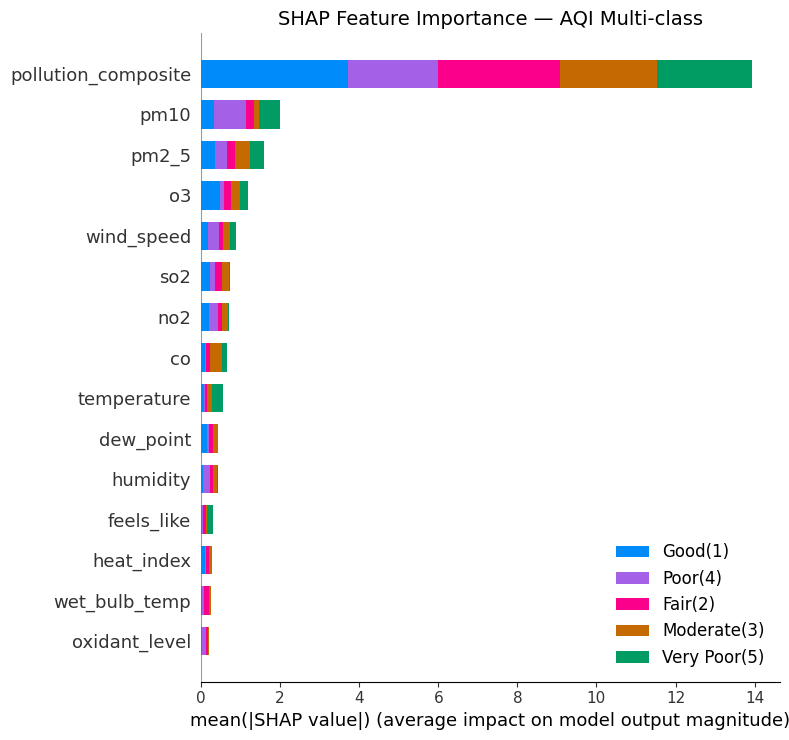

✅ SHAP done!


In [14]:
print("🔍 Computing SHAP values...")
xgb_base = stacked.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_base)

X_sample = pd.DataFrame(X_test_sc[:400], columns=FEATURE_COLS)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                  max_display=15, class_names=AQI_LABELS, show=False)
plt.title('SHAP Feature Importance — AQI Multi-class', fontsize=14)
plt.tight_layout(); plt.show()
print("✅ SHAP done!")

In [19]:
AQI_DESC  = {1:'Good', 2:'Fair', 3:'Moderate', 4:'Poor', 5:'Very Poor'}
groq_cli  = groq_client.Groq(api_key=GROQ_API_KEY)

def llm_advisory(city, feats, aqi_pred, heat_pred, top_feats):
    prompt = f"""You are an expert urban climate health advisor for {city}.

CONDITIONS:
- Temp: {feats['temperature']:.1f}°C (feels {feats['feels_like']:.1f}°C)
- Heat Index: {feats['heat_index']:.1f}°C | Humidity: {feats['humidity']:.0f}%
- PM2.5: {feats['pm2_5']:.1f} μg/m³ | NO2: {feats['no2']:.1f} | O3: {feats['o3']:.1f}
- Pollution Score: {feats['pollution_composite']:.1f}/500

ML PREDICTIONS:
- AQI: {AQI_DESC[aqi_pred]} (Level {aqi_pred}/5)
- Heat Stress: {HEAT_DESC[heat_pred]}
- Top SHAP drivers: {', '.join(top_feats)}

Write a short health advisory (under 250 words) with:
1. 🚦 Risk Summary
2. 👥 Vulnerable Groups
3. 🏃 Outdoor Activity Advice
4. 😷 3 Protective Actions"""

    resp = groq_cli.chat.completions.create(
        model="llama-3.3-70b-versatile",   # ← updated model
        messages=[{"role":"user","content":prompt}],
        max_tokens=450, temperature=0.7
    )
    return resp.choices[0].message.content

print("✅ LLM advisory function ready!")

✅ LLM advisory function ready!


In [20]:
def predict_city(city_name):
    print(f"\n{'='*55}\n🌆 ANALYSIS: {city_name.upper()}\n{'='*55}")
    raw   = fetch_city_data(city_name)
    feats = engineer_features(raw)

    # AQI prediction
    fv    = np.array([[feats[f] for f in FEATURE_COLS]])
    fv_sc = scaler.transform(fv)
    aqi_raw  = stacked.predict(fv_sc)[0]
    aqi_pred = aqi_raw + 1
    aqi_prob = stacked.predict_proba(fv_sc)[0]

    # Heat stress prediction
    hv    = np.array([[feats[f] for f in HEAT_FEATURES]])
    hv_sc = scaler_h.transform(hv)
    heat_pred = heat_model.predict(hv_sc)[0]

    # SHAP — safe extraction regardless of output shape
    fdf = pd.DataFrame(fv_sc, columns=FEATURE_COLS)
    sv  = explainer.shap_values(fdf)

    # Normalize sv to always get a 1D array of shape (n_features,)
    if isinstance(sv, list):
        # list of per-class arrays, each shape (n_samples, n_features)
        raw_shap = np.array(sv)  # → (n_classes, n_samples, n_features)
    else:
        raw_shap = np.array(sv)

    # raw_shap could be: (n_classes, n_samples, n_features) or (n_samples, n_features)
    if raw_shap.ndim == 3:
        # pick the class axis safely
        n_classes = raw_shap.shape[0]
        class_idx = min(int(aqi_raw), n_classes - 1)
        class_shap = raw_shap[class_idx, 0, :]
    elif raw_shap.ndim == 2:
        # shape (n_samples, n_features) — use the only sample
        class_shap = raw_shap[0, :]
    else:
        class_shap = raw_shap.flatten()

    top3 = [FEATURE_COLS[i] for i in np.argsort(np.abs(class_shap))[::-1][:3]]

    # Print results
    print(f"📍 {city_name}, {raw['country']}  |  {raw['lat']:.2f}°, {raw['lon']:.2f}°")
    print(f"🌡️  Temp: {feats['temperature']:.1f}°C  |  Feels: {feats['feels_like']:.1f}°C")
    print(f"💧 Humidity: {feats['humidity']:.0f}%  |  Wind: {feats['wind_speed']:.1f} m/s")
    print(f"🔥 Heat Index: {feats['heat_index']:.1f}°C  |  Dew Point: {feats['dew_point']:.1f}°C")
    print(f"💨 PM2.5: {feats['pm2_5']:.1f}  |  NO2: {feats['no2']:.1f}  |  O3: {feats['o3']:.1f}")
    print(f"🏭 Pollution Composite: {feats['pollution_composite']:.1f}/500")
    print(f"\n🤖 AQI Prediction  : {AQI_DESC[aqi_pred]} ({aqi_pred}/5)  [{aqi_prob[aqi_raw]*100:.1f}% confident]")
    print(f"🌡️  Heat Stress     : {HEAT_DESC[heat_pred]}")
    print(f"🔍 SHAP drivers    : {top3}")

    print(f"\n🧠 Generating LLM Advisory (Llama 3 / Groq)...")
    advisory = llm_advisory(city_name, feats, aqi_pred, heat_pred, top3)
    print("\n" + advisory)
    return feats, aqi_pred, heat_pred, aqi_prob, advisory

predict_city("Mumbai")


🌆 ANALYSIS: MUMBAI
📍 Mumbai, IN  |  18.97°, 72.83°
🌡️  Temp: 29.9°C  |  Feels: 36.1°C
💧 Humidity: 75%  |  Wind: 6.6 m/s
🔥 Heat Index: 36.1°C  |  Dew Point: 25.0°C
💨 PM2.5: 6.5  |  NO2: 0.1  |  O3: 40.0
🏭 Pollution Composite: 24.9/500

🤖 AQI Prediction  : Fair (2/5)  [98.0% confident]
🌡️  Heat Stress     : Extreme Caution
🔍 SHAP drivers    : ['wind_speed', 'humidity', 'temperature']

🧠 Generating LLM Advisory (Llama 3 / Groq)...

🚦 **Risk Summary**: Mumbai is currently experiencing extreme heat stress with a feels-like temperature of 36.1°C and a heat index of 36.1°C. Although the air quality is fair (AQI Level 2/5), the high humidity and temperature pose significant health risks.

👥 **Vulnerable Groups**: Elderly, young children, and people with pre-existing medical conditions are more susceptible to heat-related illnesses. Additionally, outdoor workers, athletes, and individuals with respiratory issues should take extra precautions.

🏃 **Outdoor Activity Advice**: Avoid strenuous out

({'temperature': 29.93,
  'feels_like': 36.11,
  'humidity': 75,
  'pressure': 1006,
  'wind_speed': 6.62,
  'cloud_cover': 94,
  'visibility_km': 10.0,
  'pm2_5': 6.47,
  'pm10': 32.48,
  'no2': 0.12,
  'o3': 40.02,
  'co': 80,
  'so2': 0.4,
  'pollution_composite': 24.88,
  'pm_ratio': 0.19922416181767807,
  'nox_level': 0.12,
  'oxidant_level': 40.14,
  'heat_index': 36.108586848685476,
  'dew_point': 25.002904858063975,
  'wet_bulb_temp': 26.303139858137197,
  'temp_range': 0.0,
  'feels_delta': 6.18,
  'pressure_anomaly': -7.25,
  'wind_u': 5.355692502762151,
  'wind_v': -3.891138370176174,
  'is_precipitation': 0,
  'is_fog': 0,
  'is_clear': 0,
  'visibility_stress': 0,
  'uhi_proxy': 31.84,
  'thermal_comfort_idx': 20.42943473947419,
  'owm_aqi': 2},
 np.int64(2),
 np.int64(2),
 array([0.00880478, 0.9795624 , 0.00502365, 0.00387813, 0.00273104]),
 '🚦 **Risk Summary**: Mumbai is currently experiencing extreme heat stress with a feels-like temperature of 36.1°C and a heat index o

In [21]:
COMPARE = ["Mumbai", "Delhi", "London", "Tokyo", "Dubai", "New York"]
rows = []
for city in COMPARE:
    try:
        raw = fetch_city_data(city)
        f = engineer_features(raw)
        fv_sc = scaler.transform(np.array([[f[c] for c in FEATURE_COLS]]))
        aqi = stacked.predict(fv_sc)[0] + 1
        hv_sc = scaler_h.transform(np.array([[f[c] for c in HEAT_FEATURES]]))
        hs = heat_model.predict(hv_sc)[0]
        rows.append({'city':city, 'temp':f['temperature'], 'humidity':f['humidity'],
                     'pm2_5':f['pm2_5'], 'heat_index':f['heat_index'],
                     'pollution':f['pollution_composite'], 'aqi':aqi, 'heat_stress':hs})
        print(f"  ✅ {city}")
    except Exception as e:
        print(f"  ❌ {city}: {e}")

cdf = pd.DataFrame(rows)

# Radar chart
fig = go.Figure()
metrics = ['temp','humidity','pm2_5','heat_index','pollution']
labels  = ['Temperature','Humidity','PM2.5','Heat Index','Pollution']
cdf_n = cdf.copy()
for m in metrics:
    cdf_n[m] = (cdf[m]-cdf[m].min())/(cdf[m].max()-cdf[m].min()+1e-6)

colors = px.colors.qualitative.Set2
for i, row in cdf_n.iterrows():
    vals = [row[m] for m in metrics] + [row[metrics[0]]]
    fig.add_trace(go.Scatterpolar(r=vals, theta=labels+[labels[0]],
                                  fill='toself', name=row['city'],
                                  line_color=colors[i%len(colors)], opacity=0.75))

fig.update_layout(polar=dict(radialaxis=dict(visible=True,range=[0,1])),
                  title='🌍 Multi-City Climate Risk Radar',
                  template='plotly_dark', width=750, height=580)
fig.show()

# AQI bar
fig2 = px.bar(cdf, x='city', y='aqi', color='aqi',
              color_continuous_scale=['#00e676','#ffee58','#ffa726','#ef5350','#b71c1c'],
              range_color=[1,5], title='🤖 ML Predicted AQI by City',
              template='plotly_dark')
fig2.update_layout(width=750, height=380)
fig2.show()
print(cdf[['city','temp','pm2_5','aqi','heat_stress']].to_string(index=False))

  ✅ Mumbai
  ✅ Delhi
  ✅ London
  ✅ Tokyo
  ✅ Dubai
  ✅ New York


    city  temp  pm2_5  aqi  heat_stress
  Mumbai 29.93   6.47    2            2
   Delhi 39.92  31.77    3            2
  London 14.27   0.50    2            1
   Tokyo 20.49  39.10    4            0
   Dubai 31.16  37.18    4            2
New York 29.26   7.09    3            1


In [24]:
import gradio as gr

AQI_EMOJI  = {1:'🟢', 2:'🟡', 3:'🟠', 4:'🔴', 5:'🟣'}
HEAT_EMOJI = {0:'✅', 1:'⚠️', 2:'🔶', 3:'🚨', 4:'☠️'}

def safe_shap_extract(sv, aqi_raw):
    """Safely extract 1D shap array regardless of shap version output shape"""
    raw = np.array(sv)
    if raw.ndim == 3:
        n_classes = raw.shape[0]
        class_idx = min(int(aqi_raw), n_classes - 1)
        return raw[class_idx, 0, :]
    elif raw.ndim == 2:
        return raw[0, :]
    else:
        return raw.flatten()

def gradio_predict(city_name):
    if not city_name.strip():
        return "Please enter a city.", "", ""
    try:
        raw   = fetch_city_data(city_name.strip())
        feats = engineer_features(raw)

        # AQI
        fv_sc = scaler.transform(np.array([[feats[c] for c in FEATURE_COLS]]))
        aqi_r = stacked.predict(fv_sc)[0]
        aqi   = int(aqi_r) + 1
        prob  = stacked.predict_proba(fv_sc)[0]

        # Heat stress
        hv_sc = scaler_h.transform(np.array([[feats[c] for c in HEAT_FEATURES]]))
        hs    = heat_model.predict(hv_sc)[0]

        # SHAP
        fdf  = pd.DataFrame(fv_sc, columns=FEATURE_COLS)
        sv   = explainer.shap_values(fdf)
        cs   = safe_shap_extract(sv, aqi_r)
        top3 = [FEATURE_COLS[i] for i in np.argsort(np.abs(cs))[::-1][:3]]

        summary = f"""## {AQI_EMOJI[aqi]} {city_name.title()}, {raw['country']}
| Metric | Value |
|--------|-------|
| 🌡️ Temperature | {feats['temperature']:.1f}°C (feels {feats['feels_like']:.1f}°C) |
| 💧 Humidity | {feats['humidity']:.0f}% |
| 🌬️ Wind | {feats['wind_speed']:.1f} m/s |
| 🔥 Heat Index | {feats['heat_index']:.1f}°C |
| 💨 PM2.5 | {feats['pm2_5']:.1f} μg/m³ |
| 🏭 Pollution Score | {feats['pollution_composite']:.1f}/500 |"""

        preds = f"""## 🤖 ML Predictions
**AQI:** {AQI_EMOJI[aqi]} **{AQI_DESC[aqi]}** (Level {aqi}/5) — {prob[aqi_r]*100:.1f}% confidence
**Heat Stress:** {HEAT_EMOJI[hs]} **{HEAT_DESC[hs]}**
**SHAP key drivers:** `{top3[0]}`, `{top3[1]}`, `{top3[2]}`

| Level | Probability |
|-------|-------------|
| 🟢 Good | {prob[0]*100:.1f}% |
| 🟡 Fair | {prob[1]*100:.1f}% |
| 🟠 Moderate | {prob[2]*100:.1f}% |
| 🔴 Poor | {prob[3]*100:.1f}% |
| 🟣 Very Poor | {prob[4]*100:.1f}% |"""

        advisory = llm_advisory(city_name, feats, aqi, hs, top3)
        return summary, preds, advisory

    except Exception as e:
        import traceback
        return f"❌ Error: {e}\n\n```{traceback.format_exc()}```", "", ""

with gr.Blocks(theme=gr.themes.Soft(primary_hue="purple"), title="Urban Climate AI") as demo:
    gr.Markdown("# 🌆 Urban Climate Intelligence System\n### Stacked ML Ensemble + SHAP + Llama 3 Health Advisories")
    with gr.Row():
        city_in = gr.Textbox(label="🌍 City Name", placeholder="Mumbai, Tokyo, London...", scale=3)
        btn = gr.Button("🔍 Analyze", variant="primary", scale=1)
    with gr.Row():
        out_summary  = gr.Markdown(label="Conditions")
        out_preds    = gr.Markdown(label="Predictions")
    out_advisory = gr.Markdown(label="💡 LLM Health Advisory")
    btn.click(fn=gradio_predict, inputs=[city_in], outputs=[out_summary, out_preds, out_advisory])
    gr.Examples([["Mumbai"],["Beijing"],["London"],["Phoenix"],["Singapore"]], inputs=[city_in])

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6c681c32d3cf15744b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9d726d34e2f9964026.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://6c681c32d3cf15744b.gradio.live
